---
# Introducción

In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score
from pathlib import Path
import sys

#plt.style.use('dark_background')

BASE_DIR = Path().resolve().parent
sys.path.append(str(BASE_DIR / 'scripts'))

In [2]:
df = pd.read_csv(BASE_DIR / 'data' / 'datos_entrenamiento.csv')

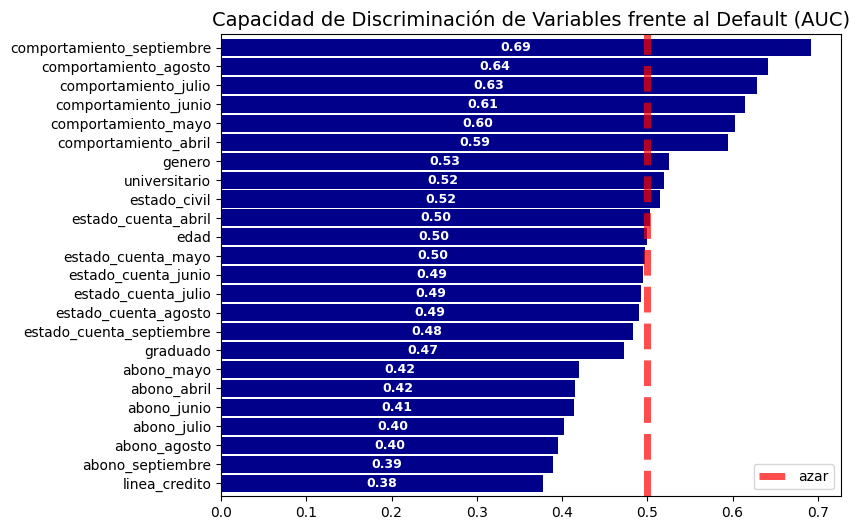

In [3]:
from graficos import grafico_auc_univariado
grafico_auc_univariado(df)

El gráfico revela que el **comportamiento reciente** (últimos 30-60 días) es el indicador de alerta temprana más confiable. Si un cliente muestra señales negativas en el último mes, el riesgo de *default* es significativamente alto ($AUC = 0.69$).

Por otro lado, la información demográfica (**edad, estado civil, género**) y el nivel de estudios tienen una capacidad de discriminación casi nula, al situarse cerca del **0.50 (azar)**. En esta misma situación de baja predictibilidad se encuentran los montos de los estados de cuenta.

Finalmente, la **línea de crédito (AUC 0.38)** indica una correlación inversa: a mayor línea de crédito, el riesgo de impago es **menor**. Lo mismo sucede con los abonos (AUC ~0.40); a mayor monto abonado, menor es el riesgo de caer en *default*."

---
# Comportamiento de pago

In [4]:
meses = ['abril', 'mayo', 'junio', 'julio', 'agosto', 'septiembre']

cols_comportamiento = [f'comportamiento_{mes}' for mes in meses]

df['conteo_retrasos'] = (df[cols_comportamiento] > 1).sum(axis=1)

print(df['conteo_retrasos'].value_counts())

conteo_retrasos
0    15110
1     2436
2     1121
3      755
6      645
4      501
5      432
Name: count, dtype: int64


A partir del historial de comportamiento de pago, se definió la variable **`conteo_retrasos`** como un indicador de persistencia de la morosidad durante todo el periodo, capturando si el incumplimiento es un evento aislado o un patrón recurrente. La distribución resultante muestra que la mayoría de los clientes (15,110) no presentó ningún mes con retraso, mientras que en el extremo opuesto, 645 clientes acumularon retraso durante los seis meses completos del período, configurando un segmento de **morosidad crónica**.

---
# Estadísticas de abono

In [5]:
cols_abono = ['abono_abril', 'abono_mayo', 'abono_junio', 
              'abono_julio', 'abono_agosto', 'abono_septiembre']

df['abono_promedio'] = df[cols_abono].mean(axis=1)
df['abono_maximo']   = df[cols_abono].max(axis=1)
df['abono_minimo']   = df[cols_abono].min(axis=1)

Se crearon las variables predictoras `abono_promedio`, `abono_maximo` y `abono_minimo`. Esto se fundamenta en la necesidad de capturar el perfil transaccional histórico del cliente:

1. **Reducción de Volatilidad y Ruido (`abono_promedio`):** Los abonos individuales suelen presentar estacionalidad o fluctuaciones atípicas (bonos, gastos imprevistos). El promedio actúa como un suavizador que estabiliza la señal de capacidad de pago.

2. **Identificación de Capacidad de Pago y Techos Financieros (`abono_maximo`):** cuantifica el compromiso financiero más alto que el cliente cumplió en el periodo. Funciona como un indicador de la liquidez máxima disponible y del comportamiento del usuario ante límites de crédito superiores.

3. **Detección de Stress Financiero y Puntos de Quiebre (`abono_minimo`):** El valor mínimo es un predictor crítico de riesgo. Un descenso significativo en el abono mínimo suele ser un indicador temprano de insolvencia o pérdida de capacidad de pago.

---
# Uso de la linea de crédito

In [6]:
meses = ['abril', 'mayo', 'junio', 'julio', 'agosto', 'septiembre']
cols_estado = [f'estado_cuenta_{m}' for m in meses]
cols_utilizacion = [f'utilizacion_{m}' for m in meses]

df[cols_utilizacion] = df[cols_estado].div(df['linea_credito'], axis=0)

df['delta_endeudamiento_6meses'] = df['utilizacion_septiembre'] - df['utilizacion_abril']
df['conteo_meses_estres_financiero'] = (df[cols_utilizacion] > 0.90).sum(axis=1)
df['utilizacion_promedio'] = df[cols_utilizacion].mean(axis=1)
df['utilizacion_maxima']   = df[cols_utilizacion].max(axis=1)
df['utilizacion_minima']   = df[cols_utilizacion].min(axis=1)

<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>utilizacion_promedio</th>
      <th>utilizacion_maxima</th>
      <th>utilizacion_minima</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0.00</th>
      <td>-0.232590</td>
      <td>-0.100000</td>
      <td>-1.395540</td>
    </tr>
    <tr>
      <th>0.01</th>
      <td>0.000000</td>
      <td>0.000000</td>
      <td>-0.019501</td>
    </tr>
    <tr>
      <th>0.02</th>
      <td>0.000000</td>
      <td>0.000000</td>
      <td>-0.005281</td>
    </tr>
    <tr>
      <th>0.98</th>
      <td>1.002183</td>
      <td>1.215528</td>
      <td>0.959275</td>
    </tr>
    <tr>
      <th>0.99</th>
      <td>1.045041</td>
      <td>1.559241</td>
      <td>0.979711</td>
    </tr>
    <tr>
      <th>1.00</th>
      <td>5.364308</td>
      <td>10.688575</td>
      <td>3.885550</td>
    </tr>
  </tbody>
</table>
</div>

In [7]:
df[[c for c in df.columns if 'utilizacion' in c]] = df[[c for c in df.columns if 'utilizacion' in c]].clip(0, 1)
df['conteo_meses_estres_financiero'] = df['conteo_meses_estres_financiero'].clip(0, 6)
df['delta_endeudamiento_6meses'] = df['delta_endeudamiento_6meses'].clip(-1, 1)

La variable `conteo_meses_estres_financiero` proporciona el número de meses que un cliente utilizó más del 90% de su linea de crédito. Se normalizó el límite de Crédito (`utilizacion_mes`) ya queEl saldo absoluto (`estado_cuenta`) es un predictor débil por sí solo. Un saldo alto no es riesgoso si el límite de crédito es proporcionalmente mayor. Al calcular la utilización, se obtiene una medida relativa de la presión financiera real que enfrenta el cliente. Por lo tanto, un cliente que utiliza consistentemente más del 90% de su línea disponible muestra señales de dependencia crediticia o falta de liquidez. Este comportamiento puede representar la antesala del impago, ya que reduce el margen de maniobra ante cualquier imprevisto económico. Además, se aprovechó a crear las variables de utilización mínima, promedio y máxima. 

---
# Clientes con perfil de alto riesgo

Un punto a considerar cuando se trabaja con estados de cuenta y abonos es; los abonos de cualquier mes, cubren estado de cuenta del mes anterior. Esto puede confirmarse en la siguiente tabla:

| Mes del estado | Mes del abono | Casos | % |
|:---|:---|---:|---:|
| Julio | Julio *(mismo mes)* | 455 | 2.2% |
| Julio | Agosto *(mes siguiente)* | 2,837 | 13.5% |
| Agosto | Agosto *(mismo mes)* | 428 | 2.0% |
| Agosto | Septiembre *(mes siguiente)* | 2,847 | 13.6% |

La consistencia entre estados de cuenta y los abonos del mes siguiente es de 13.5% para julio y 13.6% para agosto. Los casos que coinciden en el mismo mes pueden representar pagos anticipados. 

## Conteo de meses con impago

Para los clientes con saldo pendiente y sin abonos se crea una variable predictora:

In [8]:
meses_analisis = [
    ('abril', 'mayo'), ('mayo', 'junio'), ('junio', 'julio'), 
    ('julio', 'agosto'), ('agosto', 'septiembre')
]

impagos_series = [
    ((df[f'abono_{sig}'] == 0) & (df[f'estado_cuenta_{act}'] > 0)).astype(int)
    for act, sig in meses_analisis
]

df['conteo_impagos'] = sum(impagos_series)
df['conteo_impagos'].value_counts()

df['impago_agosto'] = ((df['abono_septiembre'] == 0) & (df['estado_cuenta_agosto'] > 0)).astype(int)


La variable **`conteo_impagos`** cuantifica el número de meses en los que el cliente no realizó ningún abono a pesar de tener saldo pendiente. La distribución muestra que el 52.6% de los clientes no presentó ningún mes de impago bajo esta definición, mientras que en el extremo, 116 clientes acumularon los **5 meses completos** sin realizar abono alguno, representando el segmento de mayor riesgo dentro del portafolio. Esta variable complementa a `meses_con_retraso` y `conteo_meses_estres_financiero`, aportando una dimensión adicional del comportamiento financiero del cliente basada en sus acciones de pago efectivas.

## Clientes que cubren un bajo porcentaje de su deuda

Para los clientes que abonan menos del 10% de su deuda también se definirá una variable predictora de la siguiente forma:

In [9]:
meses_pago = {'abril': 'mayo', 'mayo': 'junio', 'junio': 'julio', 'julio': 'agosto', 'agosto': 'septiembre'}

df['conteo_pago_minimo'] = sum(
    ((df[f'estado_cuenta_{est}'] > 0) & 
     (df[f'abono_{abo}'] > 0) & 
     (df[f'abono_{abo}'] <= df[f'estado_cuenta_{est}'] * 0.1)).astype(int)
    for est, abo in meses_pago.items()
)

print(df['conteo_pago_minimo'].value_counts().sort_index())

df['pago_minimo_sept'] = ((df['estado_cuenta_agosto'] > 0) & (df['abono_septiembre'] > 0) & (df['abono_septiembre'] <= df['estado_cuenta_septiembre'] * 0.1)).astype(int)

conteo_pago_minimo
0    8041
1    1858
2    1703
3    1915
4    2545
5    4938
Name: count, dtype: int64


La variable `conteo_pago_minimo` representa patrones de amortización deficiente, un indicador crítico de riesgo crediticio. Esta métrica es esencial porque un cliente que abona sistemáticamente un bajo porcentaje de deuda (maypr a 0 pero menor de 10% del saldo total) apenas cubre los intereses y comisiones generados. Esta variable captura el fenómeno de **endeudamiento "revolving" crónico**, donde la deuda principal no disminuye, incrementando exponencialmente la probabilidad de default a mediano plazo.

---
# Clientes inactivos

Buscar patrones de comportamiento en clientes inactivos es de vital importancia para comprobar que realmente pertenecen a un segmento que no tiene meses de retraso sino simplemente no utilizan la tarjeta de crédito:

In [10]:
meses = ['abril', 'mayo', 'junio', 'julio', 'agosto', 'septiembre']
cols_estado = [f'estado_cuenta_{mes}' for mes in meses]

df['conteo_meses_inactivos'] = (df[cols_estado] == 0).sum(axis=1)

print(df['conteo_meses_inactivos'].value_counts().sort_index())

conteo_meses_inactivos
0    16738
1     1299
2      822
3      559
4      518
5      459
6      605
Name: count, dtype: int64


In [11]:
df[df['conteo_meses_inactivos'] == 5]['comportamiento_agosto'].value_counts().sort_index()

comportamiento_agosto
-2    218
-1    133
 0     84
 1      5
 2     19
Name: count, dtype: int64

La variable **`conteo_meses_inactivos`**, cuenta el número de meses en los que el cliente no presentó un saldo pendiente en el estado de cuenta, indicando ausencia total de deuda activa durante ese período. La distribución muestra que el 16.738 clientes mantuvo actividad crediticia durante todos los meses, mientras que 605 clientes no registraron saldo en ninguno de los seis meses del período.

También se analizó el comportamiento de agosto de los clientes con exactamente 5 meses de inactividad, encontrando que 24 de los 459 clientes que presentan este comportamiento, en realidad tienen etiquetas de retraso con 1 o 2 meses. Este hallazgo sugiere que una fracción de los clientes clasificados como inactivos podría corresponder a deudas incobrables o también podría representar clientes que se encuentran en algún trámite especial como aclaración por cargos no reconocidos. Por esta razón, la variable se incorpora al modelo con reservas, reconociendo que la inactividad no es necesariamente una señal positiva de comportamiento financiero.

---

# Selección de características

Para este propósito se realizó mediante un modelo XGBoost:

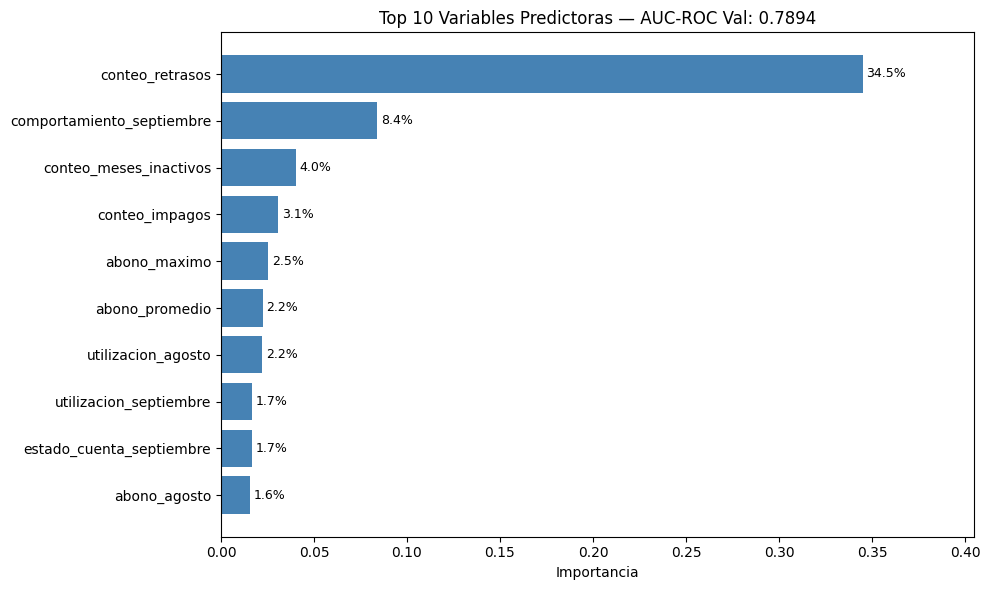

In [12]:
from graficos import importancia_de_caracteristicas
importancia_de_caracteristicas(df, target='DEFAULT', top_n=10);

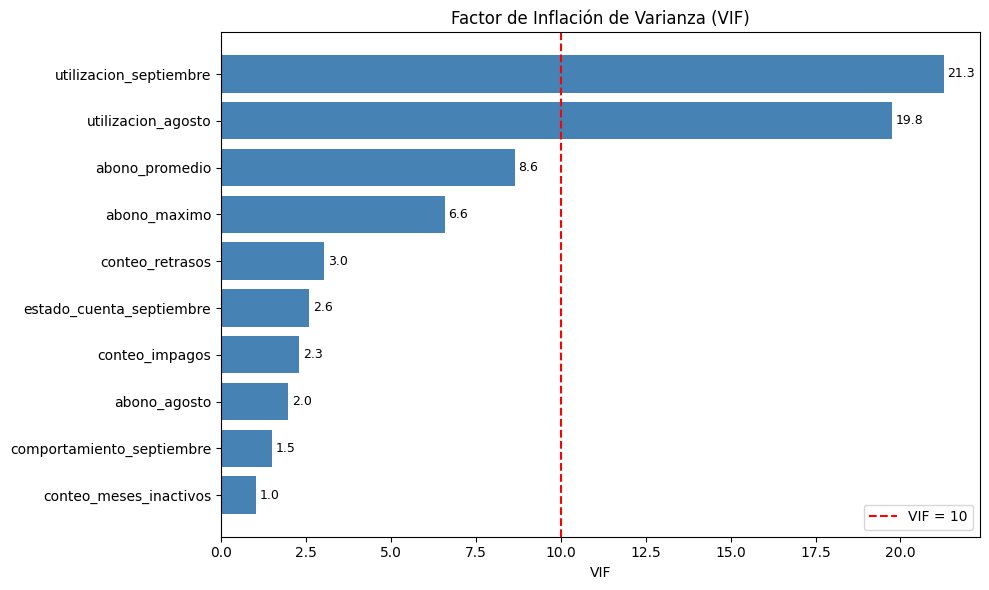

In [13]:
from graficos import factor_inflacion_varianza

X = df.drop(columns=['DEFAULT']).filter(items=[
    'conteo_retrasos',
    'comportamiento_septiembre',
    'conteo_meses_inactivos',
    'conteo_impagos',
    'abono_maximo',
    'abono_promedio',
    'utilizacion_agosto',
    'utilizacion_septiembre',
    'estado_cuenta_septiembre',
    'abono_agosto'
])

factor_inflacion_varianza(X);

Se aplicó el Factor de Inflación de Varianza (VIF) para detectar y eliminar multicolinealidad. Se eliminó 'utilización_agosto' para conservar 'utilización_septiembre' que es reciente. También se eliminó el 'abono_maximo' ya que 'abono_promedio' captura el promedio de los abonos durante 5 meses. Tras la depuración, las 8 variables restantes presentaron VIF por debajo de 3.0, indicando ausencia de multicolinealidad y garantizando que cada variable aporta información independiente al modelo.

In [14]:
df = df[[
    'conteo_retrasos',
    'comportamiento_septiembre',
    'conteo_meses_inactivos',
    'conteo_impagos',
    'abono_promedio',
    'utilizacion_septiembre',
    'estado_cuenta_septiembre',
    'DEFAULT'
]]

In [15]:
df.to_csv(BASE_DIR / 'data' / 'datos_para_modelado.csv', index=False)